# Lecture 01–02｜多模態解析、標準化與 LLM 基礎

依序執行每一格；可修改標示的參數後重跑。

## 執行前：可替換設定總覽

以下項目都可以依測試環境替換：

- `.env` Provider：填 `CILLM_API_KEY` 會走 CILLM；只有 `OPENAI_API_KEY` 時會走 OpenAI；兩者都有時 CILLM 優先。
- CILLM：`CILLM_BASE_URL`、`CILLM_USER_ID`、`CILLM_PLATFORM`、`CILLM_AGENT`、`GPT_OSS_MODEL_NAME`、`GEMMA_MODEL_NAME`。
- OpenAI：`OPENAI_API_KEY`、`OPENAI_MODEL_NAME`；本教材預設 `gpt-4o`，會同時模擬 GPT-OSS 文字與 Gemma 圖片流程。
- 密碼式 AES：第 6 章由使用者在 Notebook 隱藏輸入設定保險庫密碼；密碼不寫入 `.env` 或加密檔。
- 路徑：只有從其他工作目錄啟動 Notebook 時才需要調整 `ROOT`；一般從教材根目錄或 `notebooks/` 啟動不必修改。

> 請勿把含有真實 Key 的 `.env`、Notebook 輸出或截圖提交到 Git。

### 本章可替換

- `TEXT_PATH`：替換文字檔，例如 `flight_note.txt`、`weather_disruption_notice.txt`、`maintenance_shift_handover.txt`、`mixed_language_cabin_log.txt`。
- `IMAGE_PATH`：替換圖片，例如 `mock_boarding_pass.png`、`gate_delay_display.png`、`fictional_baggage_tag.png`、`ramp_safety_inspection.png`。
- `AUDIO_PATH`：替換音檔，例如 `sample_announcement.wav`、`weather_delay_announcement.wav`、`maintenance_handover.wav`、`passenger_service_dialogue.wav`、`bilingual_boarding_call.wav`。
- `EXCEL_PATH`：替換 Excel 檔；範例為 `flight_delays.xlsx`。
- 圖片問題文字：可修改 `analyze_image(IMAGE_PATH, 問題)` 的問題；未提供時使用預設圖片描述提示。

In [1]:
from pathlib import Path
import importlib, os, sys
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks": ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import course_utils
importlib.reload(course_utils)
from course_utils import *
print("教材根目錄：", ROOT)
connection = verify_cillm_key()
print("✅ API Key 驗證成功")
print("目前 Provider：", connection["provider"])
print("目前模型：", connection["model"])
print("首次回覆：", connection["reply"])

教材根目錄： C:\Users\rathe\Project\cillm\CILLM_Workshop\Lecture03
✅ API Key 驗證成功
目前 Provider： openai
目前模型： gpt-4o
首次回覆： CILLM 連線成功


## 檢查目前 API Key 的基本 Scope

下方 Cell 會查詢並列出這支 Key 實際具備的 RBAC scopes。本教材呼叫 GPT-OSS 至少需要 `llm.chat`。

In [2]:
scopes = get_current_key_scopes()
if scopes is None:
    print("目前使用 OpenAI API；CILLM RBAC scope 不適用。")
else:
    print("目前 CILLM_API_KEY 具備的 scopes：")
    for scope in scopes:
        print("-", scope)
    required_scope = "llm.chat"
    print(f"✅ 已具備教材基本 scope：{required_scope}" if "*" in scopes or required_scope in scopes else f"❌ 缺少教材基本 scope：{required_scope}")

目前使用 OpenAI API；CILLM RBAC scope 不適用。


> **執行模式 Hint**
>
> - 本教材每章第一格會取得 `CILLM_API_KEY`；若 `.env` 未設定，Notebook 會以隱藏輸入提示使用者填入。
> - 取得 Key 後會立即呼叫一次 `openai/gpt-oss-120b`，確認 Key 與連線可用。
> - `CILLM_BASE_URL` 預設沿用 Lecture 02 的測試端點；缺少或無效 Key 時會立即停止。
> - CILLM 模式：文字使用 GPT-OSS、圖片使用 Gemma，兩者沿用相同 CILLM API key。
> - OpenAI 模式：文字與圖片都使用 `gpt-4o`，用來模擬 GPT-OSS 與 Gemma 的教材流程。

> **換檔 Hint**
>
> - 文字：`flight_note.txt` 看部門抽取；`weather_disruption_notice.txt` 看時間與延誤；`maintenance_shift_handover.txt` 看未完成事項；`mixed_language_cabin_log.txt` 測中英混合。
> - 圖片：`mock_boarding_pass.png` 讀登機資訊；`gate_delay_display.png` 讀延誤看板；`fictional_baggage_tag.png` 讀行李路線；`ramp_safety_inspection.png` 找安全風險。
> - 語音：`weather_delay_announcement.wav` 抽取延誤資訊；`maintenance_handover.wav` 整理交班；`passenger_service_dialogue.wav` 分辨問答；`bilingual_boarding_call.wav` 測雙語轉錄。
> - Excel：`flight_delays.xlsx` 可觀察 Sheet、欄位與每列航班資料。

## 文字：先顯示原文，再進行 parse。

In [3]:
TEXT_PATH = ROOT / "data/text/flight_note.txt"
print("原始文字：")
preview_text(TEXT_PATH)
text_data = parse_text(TEXT_PATH)
print("Parse 結果："); show(text_data)

原始文字：
CI102 今日因雷雨延誤。航務部、地勤部與客服部已共同處理旅客轉接及餐點安排。

Parse 結果：
{
  "type": "text",
  "source": "flight_note.txt",
  "content": "CI102 今日因雷雨延誤。航務部、地勤部與客服部已共同處理旅客轉接及餐點安排。\n"
}


## 圖片：先顯示原圖，再交給 CILLM Gemma 或 OpenAI gpt-4o。

原始圖片：


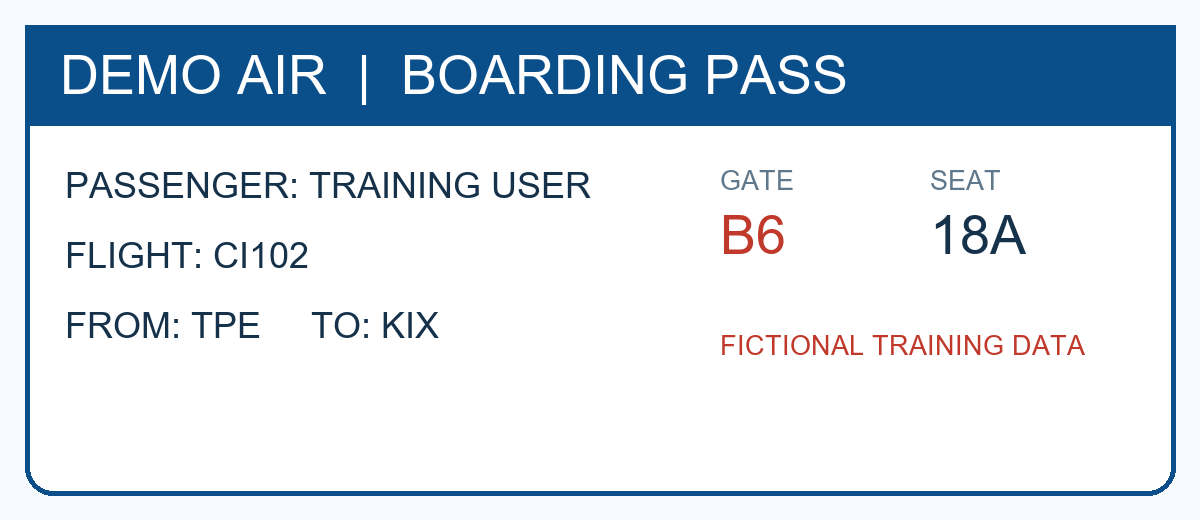

Parse 結果：
{
  "type": "image",
  "source": "mock_boarding_pass.png",
  "content": "這是一張登機證的圖片，上面寫著「DEMO AIR | BOARDING PASS」。乘客名為「TRAINING USER」，航班號碼是「CI102」，從「TPE」（台北）飛往「KIX」（關西國際機場）。登機門是「B6」，座位號碼是「18A」。底部以紅色字體標註「FICTIONAL TRAINING DATA」，表示這是虛構的訓練數據。"
}


In [4]:
IMAGE_PATH = ROOT / "data/images/mock_boarding_pass.png"
print("原始圖片：")
preview_image(IMAGE_PATH)
image_data = analyze_image(IMAGE_PATH)
print("Parse 結果："); show(image_data)

## 語音：先提供播放器，再轉錄。預設改用含人聲範例；`sample_announcement.wav` 是靜音測試檔。

In [5]:
AUDIO_PATH = ROOT / "data/audio/weather_delay_announcement.wav"
print("原始音訊：")
preview_audio(AUDIO_PATH)
audio_data = transcribe_audio(AUDIO_PATH)
print("Parse 結果："); show(audio_data)

原始音訊：


Parse 結果：
{
  "type": "audio",
  "source": "weather_delay_announcement.wav",
  "content": "各位旅客您好,Ci-203班基因讨源机场来与影响,预计延务155分钟,登基门未必12延务打两小时后,请知登基正向地情人员领取参影券"
}


## Excel：先顯示原始表格，再轉成每列「欄位是值」的文字。

In [6]:
EXCEL_PATH = ROOT / "data/excel/flight_delays.xlsx"
print("原始表格：")
preview_excel(EXCEL_PATH)
excel_data = parse_excel(EXCEL_PATH)
print("Parse 結果："); show(excel_data)

原始表格：
Sheet：delays


,flight,department,delay_minutes,passengers
0,CI101,航務部,35,286
1,CI102,地勤部,145,301
2,CI203,航務部,180,274
3,CI305,客服部,95,242
4,CI407,地勤部,125,298


Parse 結果：
{
  "type": "text",
  "source": "flight_delays.xlsx",
  "content": "flight 是 CI101、department 是 航務部、delay_minutes 是 35、passengers 是 286\nflight 是 CI102、department 是 地勤部、delay_minutes 是 145、passengers 是 301\nflight 是 CI203、department 是 航務部、delay_minutes 是 180、passengers 是 274\nflight 是 CI305、department 是 客服部、delay_minutes 是 95、passengers 是 242\nflight 是 CI407、department 是 地勤部、delay_minutes 是 125、passengers 是 298"
}


## 將四種輸入並列觀察。

In [7]:
normalized_data = [text_data, image_data, audio_data, excel_data]
show(normalized_data)
print("不同格式的資料，已完成解析與標準化。")
gpt_check = ask_gpt_oss("確認下列資料包含哪些模態，每種模態的 source 是什麼？", json.dumps(normalized_data, ensure_ascii=False))
print("GPT-OSS 檢查結果：\n", gpt_check)
print_execution_trace(question="解析四種資料並交由 GPT-OSS 確認", normalized="✓ 文字\n✓ 圖片\n✓ 語音\n✓ Excel", answer=gpt_check)

[
  {
    "type": "text",
    "source": "flight_note.txt",
    "content": "CI102 今日因雷雨延誤。航務部、地勤部與客服部已共同處理旅客轉接及餐點安排。\n"
  },
  {
    "type": "image",
    "source": "mock_boarding_pass.png",
    "content": "這是一張登機證的圖片，上面寫著「DEMO AIR | BOARDING PASS」。乘客名為「TRAINING USER」，航班號碼是「CI102」，從「TPE」（台北）飛往「KIX」（關西國際機場）。登機門是「B6」，座位號碼是「18A」。底部以紅色字體標註「FICTIONAL TRAINING DATA」，表示這是虛構的訓練數據。"
  },
  {
    "type": "audio",
    "source": "weather_delay_announcement.wav",
    "content": "各位旅客您好,Ci-203班基因讨源机场来与影响,预计延务155分钟,登基门未必12延务打两小时后,请知登基正向地情人员领取参影券"
  },
  {
    "type": "text",
    "source": "flight_delays.xlsx",
    "content": "flight 是 CI101、department 是 航務部、delay_minutes 是 35、passengers 是 286\nflight 是 CI102、department 是 地勤部、delay_minutes 是 145、passengers 是 301\nflight 是 CI203、department 是 航務部、delay_minutes 是 180、passengers 是 274\nflight 是 CI305、department 是 客服部、delay_minutes 是 95、passengers 是 242\nflight 是 CI407、department 是 地勤部、delay_minutes 是 125、passengers 是 298"
  }
]
不同格式的資料，已完成解析與標準化。
GPT-OSS 檢查

# Part 2｜將標準化資料交給 LLM

延續 Part 1 已完成的初始化與資料解析，不重複載入 Key、Provider 或 Scope。

### 本章可替換

- `USER_REQUEST`：替換使用者問題。
- `MAX_TOKENS`：替換模型最大輸出 token 數。
- `MODEL`：CILLM 模式可替換模型；OpenAI 模式以 `.env` 的 `OPENAI_MODEL_NAME` 為準。
- `system`：替換 System Prompt，調整回答角色、格式與限制。
- 輸入資料：可把 `flight_delays.xlsx` 換成 `data/` 中其他檔案，並搭配相應 parser。

> **問題 Hint**
>
> - 改問「資料中提到哪些部門？」：模型可直接依內容回答。
> - 改問「精確計算各部門平均延誤」：本章應說明缺少 Tool，而不是假裝算完。
> - 改問公司規定：本章應說明缺少 Resource。

In [8]:
# 預設情境：Excel（需要精確計算，用來觀察沒有 Tool 時的能力邊界）
# USER_REQUEST = "精確計算各部門平均延誤，然後再和我說資料中提到哪些部門？"
# normalized = parse_excel(ROOT / "data/excel/flight_delays.xlsx")

# 文字情境：從航班備註擷取事件、原因與涉及部門
# USER_REQUEST = "請整理航班備註中的班號、事件、延誤原因與涉及部門。"
# normalized = parse_text(ROOT / "data/text/flight_note.txt")

# 圖片情境：從登機證圖片整理旅客所需的登機資訊
# USER_REQUEST = "請根據圖片整理航班、起迄點、登機門、座位，並用一句話提醒旅客。"
# normalized = analyze_image(ROOT / "data/images/mock_boarding_pass.png", "請擷取圖片中的登機資訊")

# 語音情境：從延誤廣播逐字稿整理航班變更與旅客行動
# USER_REQUEST = "請整理廣播中的航班、延誤原因、時間與旅客應採取的行動。"
# normalized = transcribe_audio(ROOT / "data/audio/weather_delay_announcement.wav")

# 混合模態情境：比對文字備註與登機證圖片的航班資訊是否一致
USER_REQUEST = "請比對文字與圖片的班號與航線，列出一致和不一致的地方。"
normalized = [
    parse_text(ROOT / "data/text/flight_note.txt"),
    analyze_image(ROOT / "data/images/mock_boarding_pass.png", "請擷取班號與航線"),
]

MAX_TOKENS = 500
MODEL = "openai/gpt-oss-120b"

In [10]:
system = "你是教學助理。你沒有 Tool 或 Resource；可依輸入內容回答，但不得假裝執行計算或查詢文件。請用繁體中文說明能力限制。"
reply = call_chat(MODEL, [{"role":"system","content":system},{"role":"user","content":USER_REQUEST + "\n標準化資料：" + json.dumps(normalized,ensure_ascii=False)}], max_tokens=MAX_TOKENS)
print(reply)

由於我無法直接查看圖像，我會依賴於提供的文字內容進行比較。

根據標準化資料：
- 在 "flight_note.txt" 的文字內容中，我們看到班號是 CI102。
- 在 "mock_boarding_pass.png" 的文字內容中，我們也看到班號是 CI102，航線是從 TPE 到 KIX。

比對結果：
- 班號一致：兩個來源的班號皆為 CI102。
- 航線信息僅在圖片中提供，無法從文字內容中進行比對。因此，針對航線部分，無法判定一致或不一致。

如有其他細節或格式上的具體要求，請提供更多信息。


In [11]:
print_execution_trace(question=USER_REQUEST, normalized="✓ 已標準化輸入（文字／圖片／語音／Excel／混合模態）", tool="✗ 尚未提供", resource="✗ 尚未提供", answer=reply)

AI Agent 執行追蹤
使用者問題：
請比對文字與圖片的班號與航線，列出一致和不一致的地方。

已取得的標準化資料：
✓ 已標準化輸入（文字／圖片／語音／Excel／混合模態）

是否需要工具：
✗ 尚未提供

是否需要資源：
✗ 尚未提供

最終回答：
由於我無法直接查看圖像，我會依賴於提供的文字內容進行比較。

根據標準化資料：
- 在 "flight_note.txt" 的文字內容中，我們看到班號是 CI102。
- 在 "mock_boarding_pass.png" 的文字內容中，我們也看到班號是 CI102，航線是從 TPE 到 KIX。

比對結果：
- 班號一致：兩個來源的班號皆為 CI102。
- 航線信息僅在圖片中提供，無法從文字內容中進行比對。因此，針對航線部分，無法判定一致或不一致。

如有其他細節或格式上的具體要求，請提供更多信息。

